In [5]:
import gpytorch
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from h2_dispersion_gp import VNNGP, SparseH2DispersionGP
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

In [2]:
# Load data
df = pd.read_csv('/home/niclasflehmig/VisualCodeProjects/H2-dispersion-model/data/unified_raw_two_modes.csv')

# Sensor positions (should match your data)
SENSOR_POSITIONS = {
    1: (0.77, 0.24, 0.8), 2: (0.46, 0.0, 0.8), 3: (0.48, 0.25, 0.52),
    4: (0.13, 0.26, 0.8), 5: (0.48, 1.33, 0.52), 6: (0.46, 1.11, 0.8),
    7: (0.9, 2.22, 0.8), 8: (0.47, 2.46, 0.52), 9: (0.46, 2.22, 0.8),
    10: (0.74, 2.45, 0.8), 11: (0.15, 2.44, 0.8), 12: (0.00, 2.22, 0.8),
    13: (0.47, 3.54, 0.52), 14: (0.46, 3.31, 0.8), 15: (0.78, 4.65, 0.8),
    17: (0.46, 4.39, 0.8), 18: (0.47, 4.63, 0.52), 19: (0.14, 4.68, 0.52),
    20: (0.75, 0.24, 0.0), 21: (0.45, 0.0, 0.0), 22: (0.16, 0.24, 0.0),
    23: (0.47, 0.24, 0.28), 24: (0.46, 1.33, 0.27), 25: (0.47, 1.1, 0.0),
    26: (0.46, 2.46, 0.27), 27: (0.47, 2.23, 0.0), 28: (0.47, 3.56, 0.27),
    29: (0.47, 4.63, 0.27), 30: (0.46, 4.44, 0.0),
}

df_test = df[df['split'] == 'test'].copy()

In [13]:
checkpoint = torch.load('models/approximate_indvAdditive_svgp_rbf_4000_gaussian_two_modes_300_lr8e-3.pth_best', map_location='cpu')
inducing_points = checkpoint['model_state_dict']['variational_strategy.inducing_points']
likelihood = gpytorch.likelihoods.GaussianLikelihood().double().to('cpu')
model = SparseH2DispersionGP(inducing_points=inducing_points).double().to('cpu')

In [8]:
model_state_dict = checkpoint['model_state_dict']
likelihood_state_dict = checkpoint['likelihood_state_dict']

model.load_state_dict(model_state_dict)
likelihood.load_state_dict(likelihood_state_dict)

<All keys matched successfully>

In [12]:
import torch.nn.functional as F

state = checkpoint['model_state_dict']

for key in sorted(state.keys()):
    if 'covar_module' in key:
        val = state[key]
        if 'raw_outputscale' in key:
            print(f"{key:<50} → {F.softplus(val).item():.4f}")
        elif 'raw_lengthscale' in key:
            print(f"{key:<50} → {F.softplus(val).tolist()}")

covar_module.kernels.0.base_kernel.raw_lengthscale → [[2.4294197874839143, 4.645011468441091]]
covar_module.kernels.0.base_kernel.raw_lengthscale_constraint.lower_bound → 0.6931471805599453
covar_module.kernels.0.base_kernel.raw_lengthscale_constraint.upper_bound → inf
covar_module.kernels.0.raw_outputscale             → 0.0409
covar_module.kernels.0.raw_outputscale_constraint.lower_bound → 0.6931
covar_module.kernels.0.raw_outputscale_constraint.upper_bound → inf
covar_module.kernels.1.base_kernel.raw_lengthscale → [[2.4043269973447257, 2.658696303371859]]
covar_module.kernels.1.base_kernel.raw_lengthscale_constraint.lower_bound → 0.6931471805599453
covar_module.kernels.1.base_kernel.raw_lengthscale_constraint.upper_bound → inf
covar_module.kernels.1.raw_outputscale             → 0.0919
covar_module.kernels.1.raw_outputscale_constraint.lower_bound → 0.6931
covar_module.kernels.1.raw_outputscale_constraint.upper_bound → inf
covar_module.kernels.10.base_kernel.raw_lengthscale → [[3.4056

In [33]:
import pandas as pd
from h2_dispersion_gp import load_model, evaluate_gp_model

# 1. Load model + checkpoint
device = 'cpu'
model_4000, likelihood_4000, checkpoint_4000 = load_model('models/approximate_indvAdditive_svgp_rbf_4000_gaussian_two_modes_300_lr8e-3.pth_best', device=device)

# 2. Load test data (must be the same unified CSV used for training)
df = pd.read_csv('data/unified_raw_two_modes.csv')
df_test = df[df['split'] == 'test']

# 3. Evaluate
metrics = evaluate_gp_model(
    model=model_4000,
    likelihood=likelihood_4000,
    df_test=df_test,
    device=device,
    x_scaler=checkpoint_4000.get('x_scaler'),
    y_scaler=checkpoint_4000.get('y_scaler')
)


TEST EVALUATION
Test data: 17,545 points

Test Metrics:
  NLL:      57.0952
  MAE:      0.056802
  RMSE:     0.078750


In [34]:
x_scaler = checkpoint_4000.get('x_scaler')   # StandardScaler or None
y_scaler = checkpoint_4000.get('y_scaler')   # StandardScaler or None

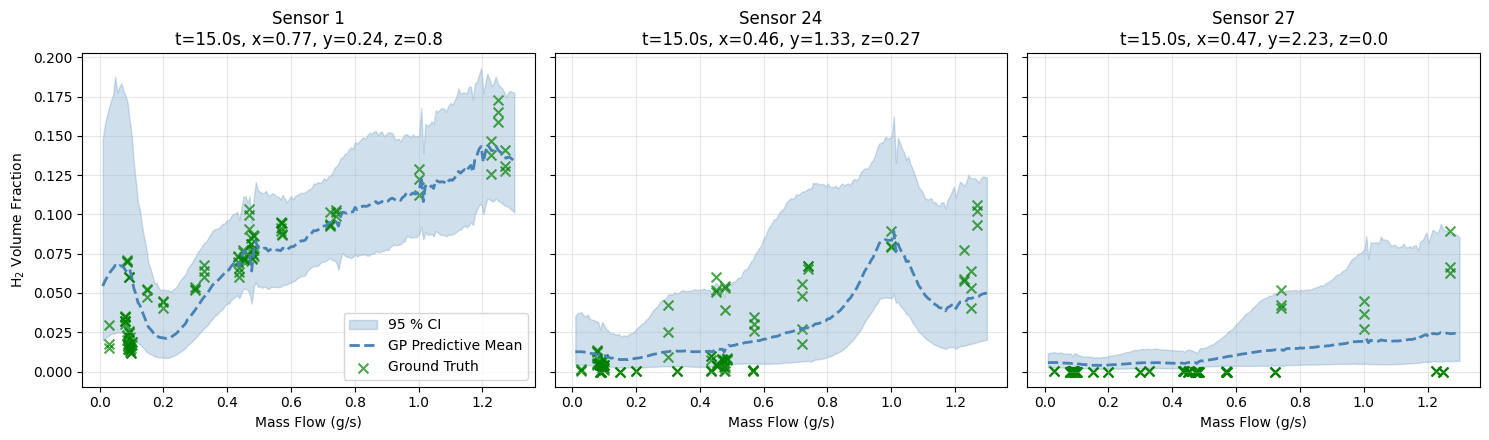

In [35]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import gpytorch

# --- Three fixed positions ---------------------------------------------------
positions = [
    {'time': 15.0, 'x': 0.77, 'y': 0.24, 'z': 0.80, 'label': 'Sensor 1'},
    {'time': 15.0, 'x': 0.46, 'y': 1.33, 'z': 0.27, 'label': 'Sensor 24'},
    {'time': 15.0, 'x': 0.47, 'y': 2.23, 'z': 0.00, 'label': 'Sensor 27'},
]

mass_flow_grid = np.linspace(0.01, 1.30, 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
axes = axes.flatten()

for ax, pos in zip(axes, positions):
    # Build input grid
    grid = np.column_stack([
        np.full_like(mass_flow_grid, pos['time']),
        mass_flow_grid,
        np.full_like(mass_flow_grid, pos['x']),
        np.full_like(mass_flow_grid, pos['y']),
        np.full_like(mass_flow_grid, pos['z']),
    ])

    if x_scaler is not None:
        grid_scaled = x_scaler.transform(grid)
    else:
        grid_scaled = grid

    X_grid = torch.tensor(grid_scaled, dtype=torch.float64, device=device)

    # Predict
    model_4000.eval()
    likelihood_4000.eval()
    with torch.no_grad():
        pred = likelihood_4000(model_4000(X_grid))
        pred_mean = pred.mean.cpu().numpy()
        lower, upper = pred.confidence_region()
        lower = lower.cpu().numpy()
        upper = upper.cpu().numpy()

    is_beta = isinstance(likelihood, gpytorch.likelihoods.BetaLikelihood)
    if not is_beta:
        if y_scaler is not None:
            pred_mean = np.exp(y_scaler.inverse_transform(pred_mean.reshape(-1, 1))).ravel()
            lower = np.exp(y_scaler.inverse_transform(lower.reshape(-1, 1))).ravel()
            upper = np.exp(y_scaler.inverse_transform(upper.reshape(-1, 1))).ravel()
        else:
            pred_mean = np.exp(pred_mean)
            lower = np.exp(lower)
            upper = np.exp(upper)

    # Ground truth
    tol = 0.01
    df_gt = df[
        (np.abs(df['time'] - pos['time']) < 1.0) &
        (np.abs(df['x'] - pos['x']) < tol) &
        (np.abs(df['y'] - pos['y']) < tol) &
        (np.abs(df['z'] - pos['z']) < tol)
    ].copy()

    # Plot
    ax.fill_between(mass_flow_grid, lower, upper, color='steelblue', alpha=0.25,
                    label='95 % CI' if ax == axes[0] else '')
    ax.plot(mass_flow_grid, pred_mean, color='steelblue', linewidth=2,
            linestyle='--', label='GP Predictive Mean' if ax == axes[0] else '')
    ax.scatter(df_gt['mass_flow'], df_gt['h2_volume_fraction'],
               c='green', marker='x', s=50, alpha=0.7,
               label='Ground Truth' if ax == axes[0] else '')

    ax.set_xlabel('Mass Flow (g/s)')
    ax.set_title(f"{pos['label']}\nt={pos['time']}s, x={pos['x']}, y={pos['y']}, z={pos['z']}")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('H$_2$ Volume Fraction')
axes[0].legend(loc='best')
plt.tight_layout()
plt.show()

## SVGP 5000

In [25]:
checkpoint = torch.load('models/approximate_indvAdditive_svgp_rbf_5000_gaussian_two_modes_300_lr8e-3.pth_best', map_location='cpu')
inducing_points = checkpoint['model_state_dict']['variational_strategy.inducing_points']
likelihood = gpytorch.likelihoods.GaussianLikelihood().double().to('cpu')
model = SparseH2DispersionGP(inducing_points=inducing_points).double().to('cpu')

In [26]:
model_state_dict = checkpoint['model_state_dict']
likelihood_state_dict = checkpoint['likelihood_state_dict']

model.load_state_dict(model_state_dict)
likelihood.load_state_dict(likelihood_state_dict)

<All keys matched successfully>

In [27]:
import torch.nn.functional as F

state = checkpoint['model_state_dict']

for key in sorted(state.keys()):
    if 'covar_module' in key:
        val = state[key]
        if 'raw_outputscale' in key:
            print(f"{key:<50} → {F.softplus(val).item():.4f}")
        elif 'raw_lengthscale' in key:
            print(f"{key:<50} → {F.softplus(val).tolist()}")

covar_module.kernels.0.base_kernel.raw_lengthscale → [[2.8837794170919704, 8.49675656056473]]
covar_module.kernels.0.base_kernel.raw_lengthscale_constraint.lower_bound → 0.6931471805599453
covar_module.kernels.0.base_kernel.raw_lengthscale_constraint.upper_bound → inf
covar_module.kernels.0.raw_outputscale             → 0.0509
covar_module.kernels.0.raw_outputscale_constraint.lower_bound → 0.6931
covar_module.kernels.0.raw_outputscale_constraint.upper_bound → inf
covar_module.kernels.1.base_kernel.raw_lengthscale → [[2.282021319852246, 3.992882058473794]]
covar_module.kernels.1.base_kernel.raw_lengthscale_constraint.lower_bound → 0.6931471805599453
covar_module.kernels.1.base_kernel.raw_lengthscale_constraint.upper_bound → inf
covar_module.kernels.1.raw_outputscale             → 0.1494
covar_module.kernels.1.raw_outputscale_constraint.lower_bound → 0.6931
covar_module.kernels.1.raw_outputscale_constraint.upper_bound → inf
covar_module.kernels.10.base_kernel.raw_lengthscale → [[5.380526

In [ ]:
# 1. Load model + checkpoint
device = 'cpu'
model_5000, likelihood_5000, checkpoint_5000 = load_model('models/approximate_indvAdditive_svgp_rbf_5000_gaussian_two_modes_300_lr8e-3.pth_best', device=device)

# 2. Load test data (must be the same unified CSV used for training)
df = pd.read_csv('data/unified_raw_two_modes.csv')
df_test = df[df['split'] == 'test']

# 3. Evaluate
metrics = evaluate_gp_model(
    model=model_5000,
    likelihood=likelihood_5000,
    df_test=df_test,
    device=device,
    x_scaler=checkpoint_5000.get('x_scaler'),
    y_scaler=checkpoint_5000.get('y_scaler')
)


TEST EVALUATION
Test data: 17,545 points

Test Metrics:
  NLL:      49.3502
  MAE:      0.058373
  RMSE:     0.079892


In [ ]:
x_scaler = checkpoint_5000.get('x_scaler')   # StandardScaler or None
y_scaler = checkpoint_5000.get('y_scaler')   # StandardScaler or None

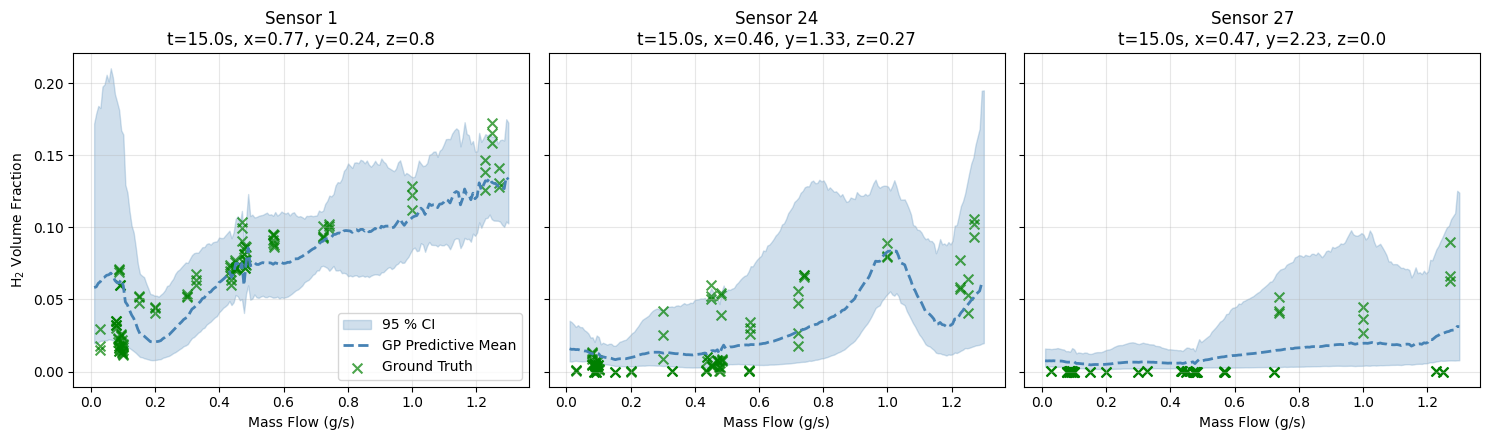

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import gpytorch

# --- Three fixed positions ---------------------------------------------------
positions = [
    {'time': 15.0, 'x': 0.77, 'y': 0.24, 'z': 0.80, 'label': 'Sensor 1'},
    {'time': 15.0, 'x': 0.46, 'y': 1.33, 'z': 0.27, 'label': 'Sensor 24'},
    {'time': 15.0, 'x': 0.47, 'y': 2.23, 'z': 0.00, 'label': 'Sensor 27'},
]

mass_flow_grid = np.linspace(0.01, 1.30, 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
axes = axes.flatten()

for ax, pos in zip(axes, positions):
    # Build input grid
    grid = np.column_stack([
        np.full_like(mass_flow_grid, pos['time']),
        mass_flow_grid,
        np.full_like(mass_flow_grid, pos['x']),
        np.full_like(mass_flow_grid, pos['y']),
        np.full_like(mass_flow_grid, pos['z']),
    ])

    if x_scaler is not None:
        grid_scaled = x_scaler.transform(grid)
    else:
        grid_scaled = grid

    X_grid = torch.tensor(grid_scaled, dtype=torch.float64, device=device)

    # Predict
    model_5000.eval()
    likelihood_5000.eval()
    with torch.no_grad():
        pred = likelihood_5000(model_5000(X_grid))
        pred_mean = pred.mean.cpu().numpy()
        lower, upper = pred.confidence_region()
        lower = lower.cpu().numpy()
        upper = upper.cpu().numpy()

    is_beta = isinstance(likelihood, gpytorch.likelihoods.BetaLikelihood)
    if not is_beta:
        if y_scaler is not None:
            pred_mean = np.exp(y_scaler.inverse_transform(pred_mean.reshape(-1, 1))).ravel()
            lower = np.exp(y_scaler.inverse_transform(lower.reshape(-1, 1))).ravel()
            upper = np.exp(y_scaler.inverse_transform(upper.reshape(-1, 1))).ravel()
        else:
            pred_mean = np.exp(pred_mean)
            lower = np.exp(lower)
            upper = np.exp(upper)

    # Ground truth
    tol = 0.01
    df_gt = df[
        (np.abs(df['time'] - pos['time']) < 1.0) &
        (np.abs(df['x'] - pos['x']) < tol) &
        (np.abs(df['y'] - pos['y']) < tol) &
        (np.abs(df['z'] - pos['z']) < tol)
    ].copy()

    # Plot
    ax.fill_between(mass_flow_grid, lower, upper, color='steelblue', alpha=0.25,
                    label='95 % CI' if ax == axes[0] else '')
    ax.plot(mass_flow_grid, pred_mean, color='steelblue', linewidth=2,
            linestyle='--', label='GP Predictive Mean' if ax == axes[0] else '')
    ax.scatter(df_gt['mass_flow'], df_gt['h2_volume_fraction'],
               c='green', marker='x', s=50, alpha=0.7,
               label='Ground Truth' if ax == axes[0] else '')

    ax.set_xlabel('Mass Flow (g/s)')
    ax.set_title(f"{pos['label']}\nt={pos['time']}s, x={pos['x']}, y={pos['y']}, z={pos['z']}")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('H$_2$ Volume Fraction')
axes[0].legend(loc='best')
plt.tight_layout()
plt.show()

# SVGP 6000

In [36]:
checkpoint = torch.load('models/approximate_indvAdditive_svgp_rbf_6000_gaussian_two_modes_300_lr8e-3.pth_best', map_location='cpu')
inducing_points = checkpoint['model_state_dict']['variational_strategy.inducing_points']
likelihood = gpytorch.likelihoods.GaussianLikelihood().double().to('cpu')
model = SparseH2DispersionGP(inducing_points=inducing_points).double().to('cpu')

In [37]:
model_state_dict = checkpoint['model_state_dict']
likelihood_state_dict = checkpoint['likelihood_state_dict']

model.load_state_dict(model_state_dict)
likelihood.load_state_dict(likelihood_state_dict)

<All keys matched successfully>

In [38]:
import torch.nn.functional as F

state = checkpoint['model_state_dict']

for key in sorted(state.keys()):
    if 'covar_module' in key:
        val = state[key]
        if 'raw_outputscale' in key:
            print(f"{key:<50} → {F.softplus(val).item():.4f}")
        elif 'raw_lengthscale' in key:
            print(f"{key:<50} → {F.softplus(val).tolist()}")

covar_module.kernels.0.base_kernel.raw_lengthscale → [[2.6994498633602566, 5.0507415182343]]
covar_module.kernels.0.base_kernel.raw_lengthscale_constraint.lower_bound → 0.6931471805599453
covar_module.kernels.0.base_kernel.raw_lengthscale_constraint.upper_bound → inf
covar_module.kernels.0.raw_outputscale             → 0.0505
covar_module.kernels.0.raw_outputscale_constraint.lower_bound → 0.6931
covar_module.kernels.0.raw_outputscale_constraint.upper_bound → inf
covar_module.kernels.1.base_kernel.raw_lengthscale → [[2.2610001549730963, 3.2886767202122904]]
covar_module.kernels.1.base_kernel.raw_lengthscale_constraint.lower_bound → 0.6931471805599453
covar_module.kernels.1.base_kernel.raw_lengthscale_constraint.upper_bound → inf
covar_module.kernels.1.raw_outputscale             → 0.1157
covar_module.kernels.1.raw_outputscale_constraint.lower_bound → 0.6931
covar_module.kernels.1.raw_outputscale_constraint.upper_bound → inf
covar_module.kernels.10.base_kernel.raw_lengthscale → [[3.26665

In [39]:
# 1. Load model + checkpoint
device = 'cpu'
model_6000, likelihood_6000, checkpoint_6000 = load_model('models/approximate_indvAdditive_svgp_rbf_6000_gaussian_two_modes_300_lr8e-3.pth_best', device=device)

# 2. Load test data (must be the same unified CSV used for training)
df = pd.read_csv('data/unified_raw_two_modes.csv')
df_test = df[df['split'] == 'test']

# 3. Evaluate
metrics = evaluate_gp_model(
    model=model_6000,
    likelihood=likelihood_6000,
    df_test=df_test,
    device=device,
    x_scaler=checkpoint_6000.get('x_scaler'),
    y_scaler=checkpoint_6000.get('y_scaler')
)


TEST EVALUATION
Test data: 17,545 points

Test Metrics:
  NLL:      45.5028
  MAE:      0.058162
  RMSE:     0.080022


In [40]:
x_scaler = checkpoint_6000.get('x_scaler')   # StandardScaler or None
y_scaler = checkpoint_6000.get('y_scaler')   # StandardScaler or None

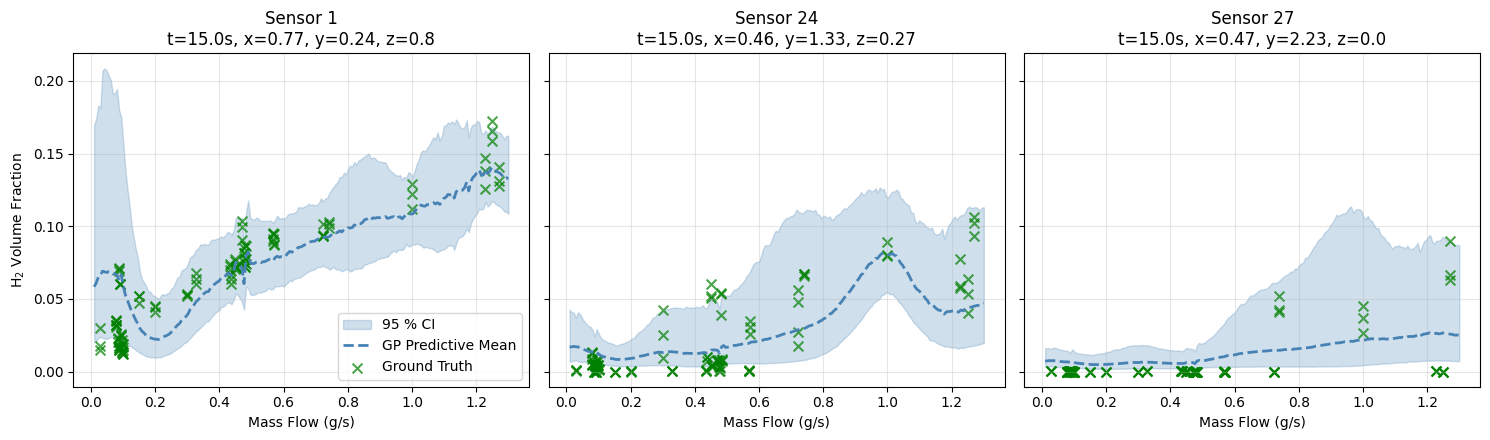

In [41]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import gpytorch

# --- Three fixed positions ---------------------------------------------------
positions = [
    {'time': 15.0, 'x': 0.77, 'y': 0.24, 'z': 0.80, 'label': 'Sensor 1'},
    {'time': 15.0, 'x': 0.46, 'y': 1.33, 'z': 0.27, 'label': 'Sensor 24'},
    {'time': 15.0, 'x': 0.47, 'y': 2.23, 'z': 0.00, 'label': 'Sensor 27'},
]

mass_flow_grid = np.linspace(0.01, 1.30, 200)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
axes = axes.flatten()

for ax, pos in zip(axes, positions):
    # Build input grid
    grid = np.column_stack([
        np.full_like(mass_flow_grid, pos['time']),
        mass_flow_grid,
        np.full_like(mass_flow_grid, pos['x']),
        np.full_like(mass_flow_grid, pos['y']),
        np.full_like(mass_flow_grid, pos['z']),
    ])

    if x_scaler is not None:
        grid_scaled = x_scaler.transform(grid)
    else:
        grid_scaled = grid

    X_grid = torch.tensor(grid_scaled, dtype=torch.float64, device=device)

    # Predict
    model_6000.eval()
    likelihood_6000.eval()
    with torch.no_grad():
        pred = likelihood_6000(model_6000(X_grid))
        pred_mean = pred.mean.cpu().numpy()
        lower, upper = pred.confidence_region()
        lower = lower.cpu().numpy()
        upper = upper.cpu().numpy()

    is_beta = isinstance(likelihood, gpytorch.likelihoods.BetaLikelihood)
    if not is_beta:
        if y_scaler is not None:
            pred_mean = np.exp(y_scaler.inverse_transform(pred_mean.reshape(-1, 1))).ravel()
            lower = np.exp(y_scaler.inverse_transform(lower.reshape(-1, 1))).ravel()
            upper = np.exp(y_scaler.inverse_transform(upper.reshape(-1, 1))).ravel()
        else:
            pred_mean = np.exp(pred_mean)
            lower = np.exp(lower)
            upper = np.exp(upper)

    # Ground truth
    tol = 0.01
    df_gt = df[
        (np.abs(df['time'] - pos['time']) < 1.0) &
        (np.abs(df['x'] - pos['x']) < tol) &
        (np.abs(df['y'] - pos['y']) < tol) &
        (np.abs(df['z'] - pos['z']) < tol)
    ].copy()

    # Plot
    ax.fill_between(mass_flow_grid, lower, upper, color='steelblue', alpha=0.25,
                    label='95 % CI' if ax == axes[0] else '')
    ax.plot(mass_flow_grid, pred_mean, color='steelblue', linewidth=2,
            linestyle='--', label='GP Predictive Mean' if ax == axes[0] else '')
    ax.scatter(df_gt['mass_flow'], df_gt['h2_volume_fraction'],
               c='green', marker='x', s=50, alpha=0.7,
               label='Ground Truth' if ax == axes[0] else '')

    ax.set_xlabel('Mass Flow (g/s)')
    ax.set_title(f"{pos['label']}\nt={pos['time']}s, x={pos['x']}, y={pos['y']}, z={pos['z']}")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('H$_2$ Volume Fraction')
axes[0].legend(loc='best')
plt.tight_layout()
plt.show()